# Week 2: Multiple Linear Regression

In this notebook, I continue my Machine Learning from Scratch journey by implementing multiple linear regression.

The goal is to understand how linear regression extends from one input feature to multiple input features, and how techniques like feature scaling, learning rate tuning, feature engineering, and polynomial regression improve the training process.

## Topics Covered

In this notebook, I cover:

* Multiple linear regression
* Vectorized prediction
* Cost function for multiple variables
* Gradient descent with multiple variables
* Feature scaling
* Learning rate tuning
* Feature engineering
* Polynomial regression

## 1. Importing Libraries

I will use NumPy for numerical operations and Matplotlib for visualizing the data and training process.

NumPy will help with vectorized calculations, while Matplotlib will be used to plot the cost function and visualize model performance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Dataset

For this notebook, I will use a small dataset with multiple input features.

Unlike simple linear regression, where there was only one input variable, multiple linear regression uses more than one feature to make predictions.

For this example, I will use a small house price dataset.

The features are:

* Size of the house
* Number of bedrooms
* Age of the house

The target value is the price of the house.

In [2]:
# Features: [size in sq ft, number of bedrooms, age of house]
X_train = np.array([
    [850, 2, 10],
    [900, 2, 8],
    [1200, 3, 6],
    [1500, 3, 4],
    [1800, 4, 3],
    [2100, 4, 2],
    [2500, 5, 1]
], dtype=float)

# Target: house price in thousands
y_train = np.array([150, 165, 220, 270, 330, 380, 450], dtype=float)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (7, 3)
y_train shape: (7,)


## 3. Multiple Linear Regression Model

In simple linear regression, the model is:

`f(x) = wx + b`

In multiple linear regression, the model uses multiple input features:

`f(x) = w1x1 + w2x2 + w3x3 + ... + b`

This can also be written in vectorized form as:

`f(x) = w · x + b`

Where:

* `w` is a vector of weights
* `x` is a vector of input features
* `b` is the bias term
* `f(x)` is the predicted output

Each feature has its own weight, which tells the model how important that feature is for the prediction.

In [3]:
def predict(X, w, b):
    
    # Calculates predictions for multiple linear regression.

    # X: training data with multiple features
    # w: weights
    # b: bias

    # returns: predicted values

    predictions = np.dot(X, w) + b
    
    return predictions

## 4. Testing the Prediction Function

Before implementing the full training algorithm, I will test the prediction function using initial values for `w` and `b`.

At the beginning, the predictions will not be accurate because the model has not been trained yet.

In [4]:
initial_w = np.zeros(X_train.shape[1])
initial_b = 0

print("Initial prediction: ", predict(X_train, initial_w, initial_b))

Initial prediction:  [0. 0. 0. 0. 0. 0. 0.]


## 5. Cost Function

The cost function measures how far the model's predictions are from the actual target values.

For multiple linear regression, the cost function is still based on mean squared error:

`J(w, b) = (1 / 2m) * sum((f(x) - y)^2)`

Where:

* `m` is the number of training examples
* `f(x)` is the predicted value
* `y` is the actual value

The goal of training is to find values of `w` and `b` that minimize the cost.

In [5]:
def compute_cost(X, y, w, b):

    # Computes the cost for multiple linear regression.

    # Parameters:
    # X: training data
    # y: target values
    # w: weights
    # b: bias

    # Returns:
    # cost: cost value
    size = X.shape[0]
    cost = 0
    for i in range(size):
        f = predict(X[i],w,b)
        cost = cost + (np.sum((f-y[i])**2))
    cost = cost / (2*size)

    return cost

## 6. Testing the Cost Function

I will now calculate the cost using the initial values of `w` and `b`.

Since the initial parameters are not trained, the cost is expected to be high.

In [6]:
initial_cost = compute_cost(X_train, y_train, initial_w, initial_b)

print("Initial Cost: ", initial_cost)

Initial Cost:  44773.21428571428


## 7. Computing Gradients

To use gradient descent, I need to calculate how much each parameter contributes to the error.

For multiple linear regression, there is one gradient for each weight in `w`, and one gradient for the bias `b`.

The gradients show the direction in which the parameters should be updated to reduce the cost.

In [7]:
def compute_gradient(X, y, w, b):

    # Computes gradients for multiple linear regression.

    # Parameters:
    # X: training data
    # y: target values
    # w: weights
    # b: bias

    # Returns:
    # dj_dw: gradient for weights
    # dj_db: gradient for bias
    
    size = X.shape[0]
    dj_db =0
    dj_dw = 0

    for x in range(size):
        f = predict(X[x], w, b)
        dj_dw = dj_dw + (f-y[x]) * X[x]
        dj_db = dj_db + (f-y[x])
    dj_db = dj_db/size
    dj_dw = dj_dw/size
    
    return dj_dw, dj_db

## 8. Gradient Descent

Gradient descent is used to update the parameters `w` and `b`.

The model repeatedly:

1. Makes predictions
2. Calculates the error
3. Computes gradients
4. Updates the parameters
5. Repeats the process to reduce the cost

The update rule is:

`w = w - α * gradient_w`

`b = b - α * gradient_b`

Where:

* `α` is the learning rate
* `gradient_w` tells us how to update the weights
* `gradient_b` tells us how to update the bias

If gradient descent is working correctly, the cost should decrease over time.

In [8]:
def gradient_descent(X, y, w, b, alpha, iterations):

    # Runs gradient descent.

    # Parameters:
    # X: training data
    # y: target values
    # w: initial weights
    # b: initial bias
    # alpha: learning rate
    # iterations: number of iterations

    # Returns:
    # w: final learned weights
    # b: final learned bias
    # cost_history: cost values during training
    
    cost_history = []
    
    for i in range(iterations):
       dj_dw, dj_db = compute_gradient(X,y,w,b)
       w = w - alpha*dj_dw
       b = b- alpha*dj_db

       cost_history.append(compute_cost(X,y,w,b))
    
    return w, b, cost_history

## 9. Training Without Feature Scaling

First, I will train the model without feature scaling.

This will help show why feature scaling is useful when features have very different ranges.

In [9]:
w = np.zeros(X_train.shape[1])
b = 0

iterations = 1000
alpha = 0.000000001

w_final, b_final, cost_history = gradient_descent(X_train, y_train, w, b, alpha, iterations)

print(f"Final values:  w = {np.round(w_final,4)} b = {b_final:.4f}")
print("Final cost: ", cost_history[-1])


Final values:  w = [0.1693 0.0004 0.0004] b = 0.0001
Final cost:  192.12651042490415


## 10. Visualizing the Cost

Plotting the cost over iterations helps show whether gradient descent is working correctly.

If the model is learning, the cost should decrease over time.

If the cost increases or becomes unstable, the learning rate may be too large.

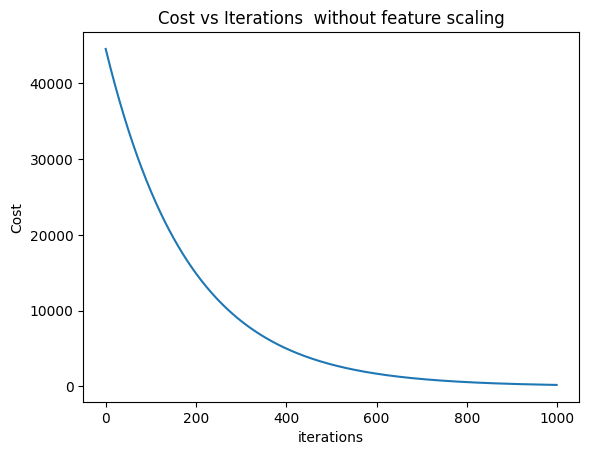

In [10]:
plt.plot(cost_history)
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations  without feature scaling")

plt.show()

## 11. Feature Scaling

Feature scaling is used to bring features into a similar range.

This is important because different features can have very different values.

For example:

* House size may range from 500 to 3000
* Number of bedrooms may range from 1 to 5

If the features have very different scales, gradient descent can become slow or inefficient.

One common method is z-score normalization:

`x_scaled = (x - mean) / standard_deviation`

Feature scaling helps gradient descent converge faster.

In [11]:
def z_score_normalize(X):
    
    # Applies z-score normalization.

    # Parameters:
    # X: input features

    # Returns:
    # X_norm: normalized features
    # mu: mean of each feature
    # sigma: standard deviation of each feature
    
    mu = np.mean(X,axis = 0)
    sigma = np.std(X, axis=0)
    
    X_norm = (X-mu)/sigma
    return X_norm, mu, sigma

## 12. Training After Feature Scaling

After scaling the features, I will train the model again using gradient descent.

The purpose of this step is to compare training before and after feature scaling.

Feature scaling should make gradient descent faster and more stable.

In [12]:
X_norm, mu, sigma = z_score_normalize(X_train)
w = np.zeros(X_norm.shape[1])
b = 0

iterations = 50
alpha = 0.1

w_norm, b_norm, cost_history = gradient_descent(X_norm, y_train, w, b, alpha, iterations)

print(f"Scaled values:  w = {np.round(w_norm,4)} b = {b_norm:.4f}")
print("Scaled cost: ", cost_history[-1])


Scaled values:  w = [ 41.3925  34.2173 -28.8052] b = 279.2675
Scaled cost:  46.26124917646195


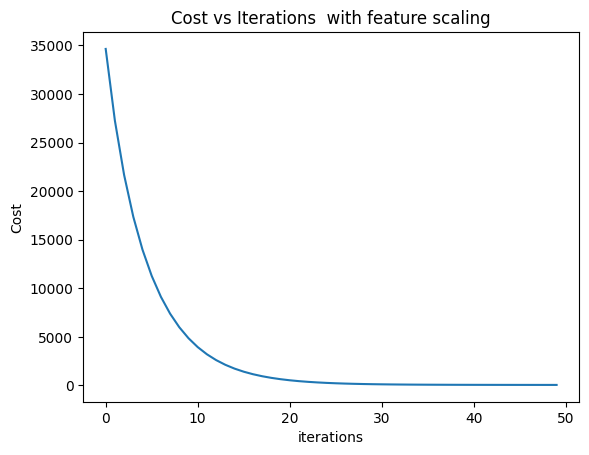

In [13]:
plt.plot(cost_history)
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations  with feature scaling")

plt.show()

## Comparison: With and Without Feature Scaling

The two cost plots show the effect of feature scaling on gradient descent.

Without feature scaling, the cost decreases slowly and requires many more iterations to get close to the minimum. This happens because the features have very different ranges, causing gradient descent to take less efficient steps.

With feature scaling, the cost decreases much faster. The model reaches a low cost in far fewer iterations because all features are brought into a similar range.

This shows that feature scaling does not change the linear regression algorithm itself, but it makes gradient descent converge much faster and more reliably.

## 13. Learning Rate Experiments

The learning rate controls how large each gradient descent step is.

If the learning rate is too small, gradient descent will be very slow.

If the learning rate is too large, gradient descent may overshoot the minimum and fail to converge.

A good learning rate should make the cost decrease steadily over time.

In this section, I compare different learning rates and observe how they affect training.

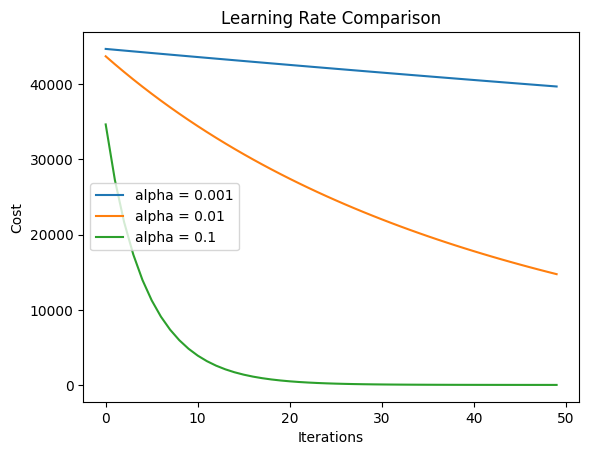

In [14]:
learning_rates = [0.001, 0.01, 0.1]
iterations = 50
w = np.zeros(X_norm.shape[1])
b = 0

for alpha in learning_rates:
   temp_cost_history = gradient_descent(X_norm, y_train, w, b, alpha, iterations)[2]
   plt.plot(temp_cost_history, label=f"alpha = {alpha}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

## Learning Rate Comparison

This plot compares how different learning rates affect gradient descent after feature scaling.

The learning rates tested were:

* `alpha = 0.001`
* `alpha = 0.01`
* `alpha = 0.1`

From the graph, `alpha = 0.001` decreases the cost very slowly. This means the learning rate is too small, so gradient descent takes very small steps.

`alpha = 0.01` performs better than `0.001`, but it still takes more iterations to reduce the cost significantly.

`alpha = 0.1` gives the best result in this experiment. The cost decreases quickly and reaches a much lower value within 50 iterations.

This shows that choosing a good learning rate is important. A very small learning rate makes training slow, while a suitable learning rate helps gradient descent converge much faster.


## Polynomial Regression

Polynomial regression is a type of feature engineering.

Instead of only using the original feature `x`, I can create new features such as:

`x, x², x³`

This allows linear regression to fit curved patterns while still using the same gradient descent algorithm.

In [15]:
x_poly = X_train[:, 0]

X_poly = np.column_stack((x_poly, x_poly**2, x_poly**3))

print("Original x shape:", x_poly.shape)
print("Polynomial X shape:", X_poly.shape)
print(X_poly)


Original x shape: (7,)
Polynomial X shape: (7, 3)
[[8.50000e+02 7.22500e+05 6.14125e+08]
 [9.00000e+02 8.10000e+05 7.29000e+08]
 [1.20000e+03 1.44000e+06 1.72800e+09]
 [1.50000e+03 2.25000e+06 3.37500e+09]
 [1.80000e+03 3.24000e+06 5.83200e+09]
 [2.10000e+03 4.41000e+06 9.26100e+09]
 [2.50000e+03 6.25000e+06 1.56250e+10]]


## Scaling Polynomial Features

Polynomial features can become very large.

For example, if house size is `2000`, then:

`2000² = 4,000,000`

`2000³ = 8,000,000,000`

Because of this, polynomial features should be scaled before training.

I will use the same z-score normalization function that I used earlier.

In [16]:
X_poly_norm, mu_poly, sigma_poly = z_score_normalize(X_poly)

w = np.zeros(X_poly_norm.shape[1])
b = 0

alpha = 0.1
iterations = 100

w_poly, b_poly, cost_history_poly = gradient_descent(X_poly_norm, y_train, w, b, alpha, iterations)

print("Polynomial weights:", np.round(w_poly, 4))
print("Polynomial bias:", b_poly)
print("Polynomial final cost:", cost_history_poly[-1])

Polynomial weights: [52.6739 33.8284 16.5708]
Polynomial bias: 280.70682955016935
Polynomial final cost: 62.686864360278186


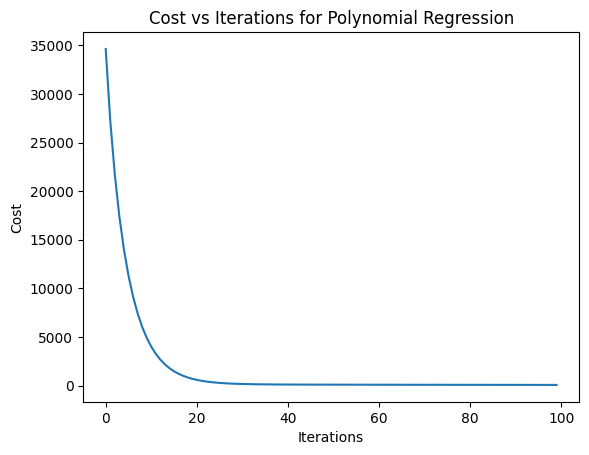

In [17]:
plt.plot(cost_history_poly)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations for Polynomial Regression")
plt.show()

## Visualizing Polynomial Regression

Since polynomial regression uses one original feature, house size, I can visualize the fitted curve.

To do this, I will create a smooth range of house sizes, convert those values into polynomial features, scale them using the same mean and standard deviation, and then make predictions.

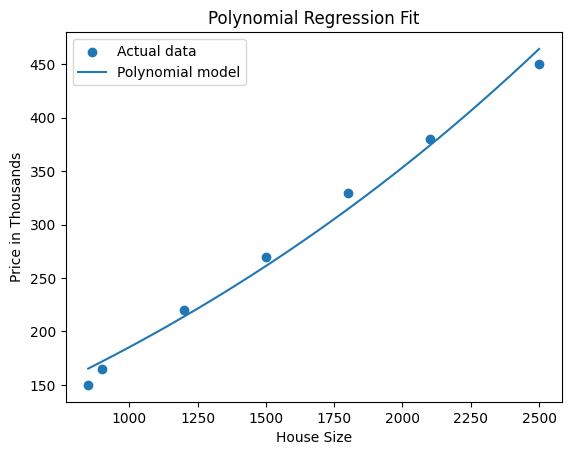

In [18]:
x_range = np.linspace(min(x_poly), max(x_poly), 100)

X_range_poly = np.column_stack((x_range, x_range**2, x_range**3))

X_range_poly_norm = (X_range_poly - mu_poly) / sigma_poly

y_pred_poly = predict(X_range_poly_norm, w_poly, b_poly)

plt.scatter(x_poly, y_train, label="Actual data")

plt.plot(x_range, y_pred_poly, label="Polynomial model")

plt.xlabel("House Size")
plt.ylabel("Price in Thousands")
plt.title("Polynomial Regression Fit")
plt.legend()
plt.show()

## Final Summary

In this notebook, I implemented multiple linear regression from scratch.

I extended simple linear regression to multiple input features, implemented vectorized prediction, calculated the cost function, computed gradients, and trained the model using gradient descent.

I also explored how feature scaling improves gradient descent and how different learning rates affect convergence.

Finally, I used polynomial regression by creating polynomial features from house size. This showed how linear regression can model curved relationships while still using the same gradient descent algorithm.